In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from matplotlib import figure
plt.figure(figsize=(10, 6))


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [19]:
data=pd.read_csv("diabetes.csv")

In [20]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,767.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.642764,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.469180,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.500000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [21]:
data.isna().sum()

Pregnancies                 0
Glucose                     1
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [22]:
def clean_col(df,columnName):
    if(df[columnName].isna().sum())>0:
        df[columnName].fillna(df[columnName].mean(),inplace=True)
#outlier
    q1=df[columnName].quantile(0.10)
    q3=df[columnName].quantile(0.90)
    iqr=q3-q1
    lower_bound= q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    print((df[columnName]<lower_bound).sum())
    print((df[columnName]>upper_bound).sum())

    df[columnName]=np.where(df[columnName]<lower_bound,lower_bound,df[columnName])
    df[columnName]=np.where(df[columnName]>upper_bound,upper_bound,df[columnName])


In [23]:
#columns_to_clean=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for column in data.columns:
    clean_col(data,column)

0
0
0
0
0
0
0
1
0
18
0
0
0
4
0
0
0
0


C:\Users\vmadh\AppData\Local\Temp\ipykernel_30648\3264944406.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[columnName].fillna(df[columnName].mean(),inplace=True)


In [24]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<Axes: xlabel='Glucose'>

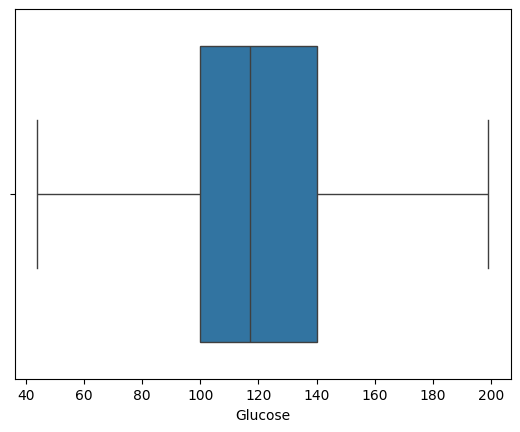

In [25]:
sns.boxplot(data=data,x="Glucose")

In [26]:
X=data.drop("Outcome",axis=1)
y=data["Outcome"]

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    float64
dtypes: float64(9)
memory usage: 54.1 KB


In [28]:
data['HighRisk']= data.apply(lambda x:1 if(x['Glucose'] >150) & (x['Age'] >40) else 0,axis=1)

In [31]:
data.loc[data['HighRisk']==1]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,HighRisk
8,2.0,197.0,70.0,45.0,424.5,30.5,0.158,53.0,1.0,1
13,1.0,189.0,60.0,23.0,424.5,30.1,0.398,59.0,1.0,1
14,5.0,166.0,72.0,19.0,175.0,25.8,0.587,51.0,1.0,1
22,7.0,196.0,90.0,32.0,169.5,39.8,0.451,41.0,1.0,1
43,9.0,171.0,110.0,24.0,240.0,45.4,0.721,54.0,1.0,1
53,8.0,176.0,90.0,34.0,300.0,33.7,0.467,58.0,1.0,1
56,7.0,187.0,68.0,39.0,304.0,37.7,0.254,41.0,1.0,1
111,8.0,155.0,62.0,26.0,424.5,34.0,0.543,46.0,1.0,1
152,9.0,156.0,86.0,28.0,155.0,34.3,1.189,42.0,1.0,1
154,8.0,188.0,78.0,32.0,169.5,47.9,0.137,43.0,1.0,1


In [32]:
print(data['HighRisk'].value_counts())

HighRisk
0    715
1     53
Name: count, dtype: int64


In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [34]:
n_estimators=[100,200,300,500]
rf=RandomForestClassifier(n_estimators=n_estimators,random_state=42)

In [35]:
ada=AdaBoostClassifier(n_estimators=100,random_state=42)

In [36]:
rf.fit(X_train,y_train)
ada.fit(X_train,y_train)

InvalidParameterError: The 'n_estimators' parameter of RandomForestClassifier must be an int in the range [1, inf). Got [100, 200, 300, 500] instead.

In [ ]:
rf.predict(X_test)
ada.predict(X_test)